# Procesamiento Digital de Imágenes
## Guía de Trabajos Prácticos 6 — Restauración de imagenes
**FICH, UNL — Ingeniería Informática**

## Ejercicio 1 Modelos de Ruido

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets

def modelos_de_ruido(tipo_ruido, param1, param2):
    # 1. Generar imagen de 600x600 con 3 franjas verticales de grises (60, 120, 180)
    img_franjas = np.zeros((600, 600), dtype=np.uint8)
    img_franjas[:, :200] = 60    # Oscuro
    img_franjas[:, 200:400] = 120  # Medio
    img_franjas[:, 400:] = 180   # Claro

    img_ruidosa = img_franjas.copy()

    # 2. Generación de ruido y aplicación a la imagen
    if tipo_ruido == 'Gaussiano':
        # param1 = desvío estándar (sigma). Media seteada a 0.
        ruido = np.random.normal(0, param1, img_franjas.shape)
        img_ruidosa = np.clip(img_franjas.astype(np.float32) + ruido, 0, 255).astype(np.uint8)
        
    elif tipo_ruido == 'Uniforme':
        # param1 = rango (a). Va de -a hasta a para que la media sea 0.
        ruido = np.random.uniform(-param1, param1, img_franjas.shape)
        img_ruidosa = np.clip(img_franjas.astype(np.float32) + ruido, 0, 255).astype(np.uint8)
        
    elif tipo_ruido == 'Exponencial':
        ruido = np.random.exponential(param1, img_franjas.shape) - param1
        img_ruidosa = np.clip(img_franjas.astype(np.float32) + ruido, 0, 255).astype(np.uint8)
        
    elif tipo_ruido == 'Sal y Pimienta':
        p_sal = param1 / 100.0
        p_pim = param2 / 100.0
        matriz_rand = np.random.rand(*img_franjas.shape)
        img_ruidosa[matriz_rand < p_sal] = 255
        img_ruidosa[(matriz_rand >= p_sal) & (matriz_rand < p_sal + p_pim)] = 0
        
    elif tipo_ruido == 'Impulsivo Unimodal':
        # param1 = probabilidad (%), param2 = intensidad del impulso (ej. 255)
        p_impulso = param1 / 100.0
        matriz_rand = np.random.rand(*img_franjas.shape)
        img_ruidosa[matriz_rand < p_impulso] = int(param2)

    # 3. Visualización
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    
    axs[0, 0].imshow(img_franjas, cmap='gray', vmin=0, vmax=255)
    axs[0, 0].set_title("Original (3 Franjas)")
    axs[0, 0].axis('off')
    
    axs[0, 1].hist(img_franjas.ravel(), bins=256, range=(0, 255), color='gray')
    axs[0, 1].set_title("Histograma Original")
    
    axs[1, 0].imshow(img_ruidosa, cmap='gray', vmin=0, vmax=255)
    axs[1, 0].set_title(f"Con Ruido: {tipo_ruido}")
    axs[1, 0].axis('off')
    
    axs[1, 1].hist(img_ruidosa.ravel(), bins=256, range=(0, 255), color='gray')
    axs[1, 1].set_title("Histograma Ruidoso")
    
    plt.tight_layout()
    plt.show()

# Interfaz interactiva
interact(modelos_de_ruido, 
         tipo_ruido=widgets.Dropdown(options=['Gaussiano', 'Uniforme', 'Exponencial', 'Sal y Pimienta', 'Impulsivo Unimodal'], value='Gaussiano', description='Tipo Ruido:'),
         param1=widgets.FloatSlider(min=0, max=100, value=20, step=1, description='Parám 1:', style={'description_width': 'initial'}),
         param2=widgets.FloatSlider(min=0, max=255, value=20, step=1, description='Parám 2:'))

interactive(children=(Dropdown(description='Tipo Ruido:', options=('Gaussiano', 'Uniforme', 'Exponencial', 'Sa…

<function __main__.modelos_de_ruido(tipo_ruido, param1, param2)>

## Ejercicio 2 Filtros de medias

In [10]:
def filtros_de_medias_interact(ksize, Q):
    # Intentamos cargar 'sangre.jpg'. 
    # (Asegurate de que esté en la misma carpeta que tu notebook)
    img = cv2.imread('sangre.jpg', cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Cuidado: No se encontró 'sangre.jpg'. Usando imagen generada de prueba.")
        img = np.zeros((300, 300), dtype=np.uint8)
        cv2.circle(img, (150, 150), 50, 255, -1)
        cv2.rectangle(img, (50, 50), (100, 100), 150, -1)
        
    # 1. Contaminar con mezcla de ruido impulsivo y gaussiano
    img_degradada = img.copy()
    
    # Ruido Gaussiano (media=0, std=15)
    ruido_gaussiano = np.random.normal(0, 15, img.shape)
    img_degradada = np.clip(img_degradada.astype(np.float32) + ruido_gaussiano, 0, 255).astype(np.uint8)
    
    # Ruido Impulsivo (Sal y Pimienta, 2% de cada uno)
    p_sal = 0.02
    p_pim = 0.02
    matriz_rand = np.random.rand(*img.shape)
    img_degradada[matriz_rand < p_sal] = 255
    img_degradada[(matriz_rand >= p_sal) & (matriz_rand < p_sal + p_pim)] = 0
    
    # Convertimos a float32 y sumamos un épsilon (1e-7) para evitar errores de log(0) o div/0
    img_float = img_degradada.astype(np.float32) + 1e-7
    
    # 2. Filtro de Media Geométrica
    # Hint aplicado: img_geom = exp(filtro_promedio(log(img)))
    img_log = np.log(img_float)
    img_log_blur = cv2.blur(img_log, (ksize, ksize))
    img_media_geom = np.exp(img_log_blur)
    img_media_geom = np.clip(img_media_geom, 0, 255).astype(np.uint8)
    
    # 3. Filtro de Media Contra-armónica
    # Numerador = suma(pixeles^(Q+1)) / Denominador = suma(pixeles^Q)
    # Como cv2.blur calcula el promedio (suma/N), dividir los promedios cancela la N y equivale a dividir las sumas.
    num = cv2.blur(np.power(img_float, Q + 1), (ksize, ksize))
    den = cv2.blur(np.power(img_float, Q), (ksize, ksize))
    img_contra_arm = num / den
    img_contra_arm = np.clip(img_contra_arm, 0, 255).astype(np.uint8)
    
    # 4. Evaluación cuantitativa (Cálculo del ECM)
    def mse(imageA, imageB):
        err = np.sum((imageA.astype("float") - imageB.astype("float")) ** 2)
        err /= float(imageA.shape[0] * imageA.shape[1])
        return err
        
    ecm_degradada = mse(img, img_degradada)
    ecm_geom = mse(img, img_media_geom)
    ecm_contra = mse(img, img_contra_arm)
    
    print(f"ECM Degradada vs Original: {ecm_degradada:.2f}")
    print(f"ECM Media Geométrica: {ecm_geom:.2f}")
    print(f"ECM Media Contra-armónica (Q={Q}): {ecm_contra:.2f}")
    
    # 5. Visualización
    fig, axs = plt.subplots(1, 4, figsize=(18, 5))
    
    axs[0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axs[0].set_title("Original Limpia")
    axs[0].axis('off')
    
    axs[1].imshow(img_degradada, cmap='gray', vmin=0, vmax=255)
    axs[1].set_title(f"Degradada (ECM: {ecm_degradada:.1f})")
    axs[1].axis('off')
    
    axs[2].imshow(img_media_geom, cmap='gray', vmin=0, vmax=255)
    axs[2].set_title(f"Geométrica (ECM: {ecm_geom:.1f})")
    axs[2].axis('off')
    
    axs[3].imshow(img_contra_arm, cmap='gray', vmin=0, vmax=255)
    axs[3].set_title(f"Contra-armónica (ECM: {ecm_contra:.1f})")
    axs[3].axis('off')
    
    plt.tight_layout()
    plt.show()

interact(filtros_de_medias_interact, 
         ksize=widgets.IntSlider(min=3, max=15, step=2, value=3, description='Kernel Size:'),
         Q=widgets.FloatSlider(min=-5.0, max=5.0, step=0.5, value=1.5, description='Parámetro Q:'))

interactive(children=(IntSlider(value=3, description='Kernel Size:', max=15, min=3, step=2), FloatSlider(value…

<function __main__.filtros_de_medias_interact(ksize, Q)>

**Fallo de la Media Geométrica:** Visualmente la imagen se llenó de manchas negras y su error es ECM: 3225.2. Este filtro falla al basarse en la multiplicación de píxeles, un solo píxel negro de ruido (valor 0 o muy bajo) arrastra todo el resultado de ese vecindario hacia el negro.

**Éxito de la Media Contra-armónica (Q=1.5):** Limpió la imagen y logró el menor error de todos (ECM bajó a 290.7, mejorando la degradada original).

## Ejercicio 3 Filtros de orden

--- Evaluación Cuantitativa (ECM) ---
ECM Degradada:                  905.18
ECM (a) Mediana:                114.85
ECM (b) Punto Medio:            926.61
ECM (c) Alfa-recortado (d=4):  102.83
ECM (d) Cascada (Med -> P.Med): 216.84


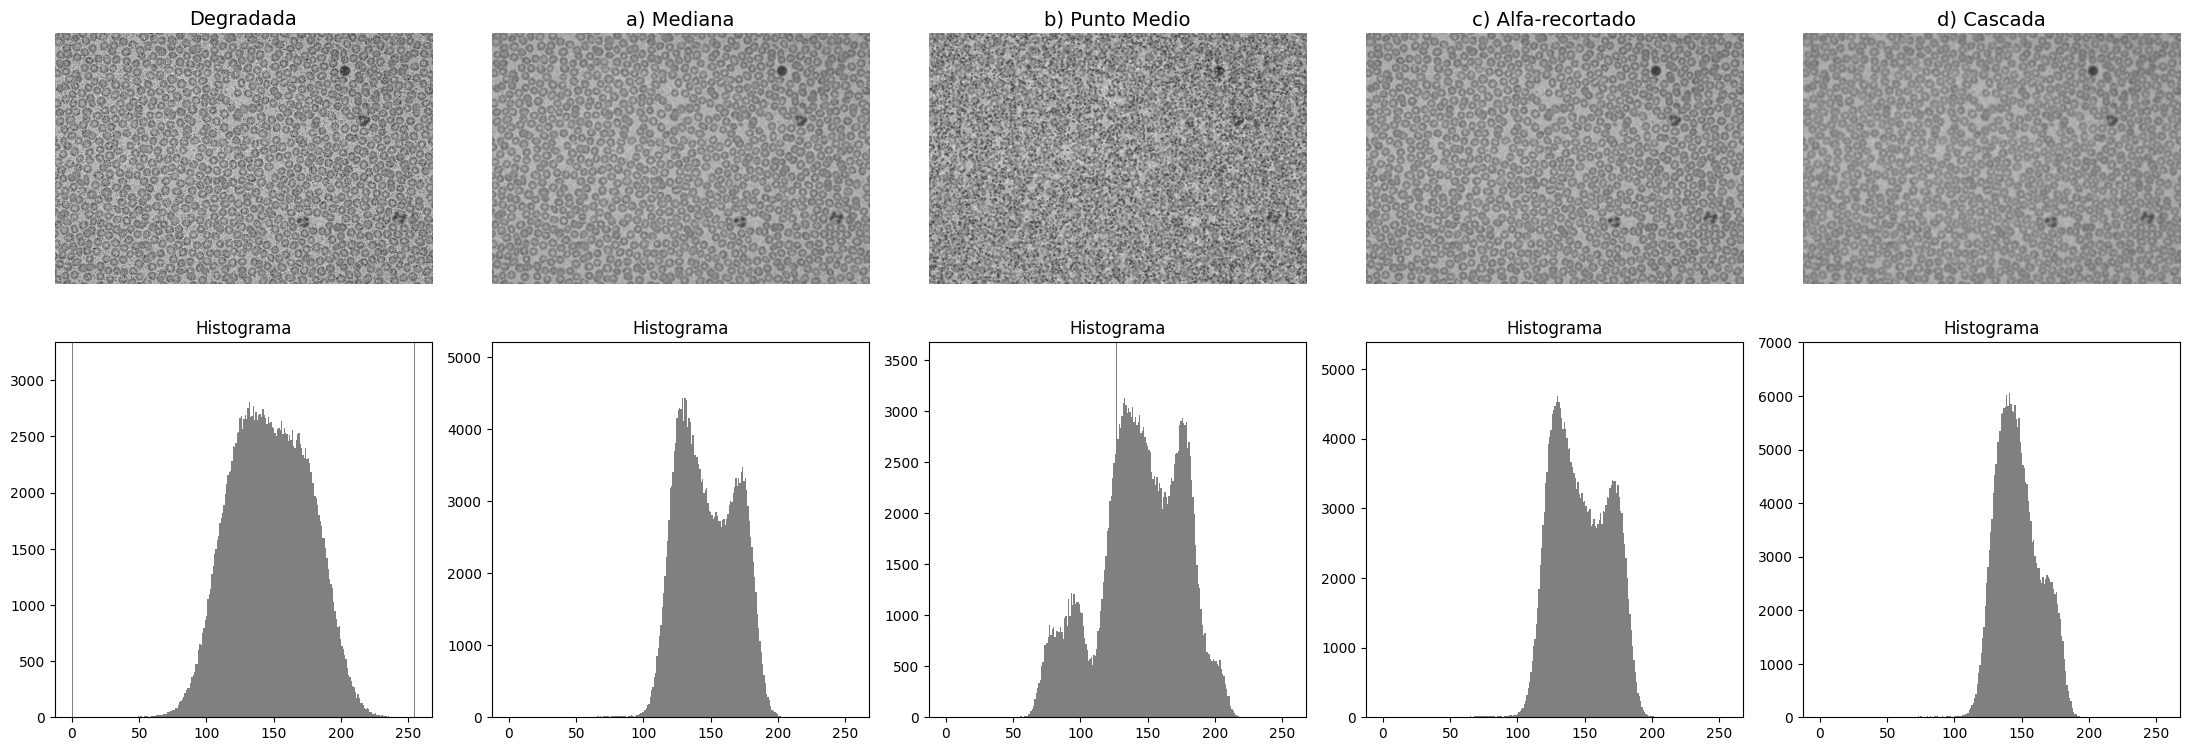

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter, minimum_filter, generic_filter

def ejercicio_3_filtros_orden():
    # Cargar la imagen
    img = cv2.imread('sangre.jpg', cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("No se encontró 'sangre.jpg'. ")
        return

    # ---------------------------------------------------------
    # 0. Recrear la misma imagen degradada del Ejercicio 2
    # ---------------------------------------------------------
    img_ruidosa = img.copy().astype(np.float32)
    np.random.seed(42) # Fijamos semilla para que el ruido sea siempre igual
    
    # Ruido Gaussiano
    img_ruidosa += np.random.normal(0, 15, img.shape)
    
    # Ruido Impulsivo (Sal y Pimienta)
    prob_sal, prob_pim = 0.02, 0.02
    matriz_rand = np.random.rand(*img.shape)
    img_ruidosa[matriz_rand < prob_sal] = 255
    img_ruidosa[(matriz_rand >= prob_sal) & (matriz_rand < prob_sal + prob_pim)] = 0
    
    img_deg = np.clip(img_ruidosa, 0, 255).astype(np.uint8)
    img_float = img_deg.astype(np.float32)
    
    ksize = 3 # Tamaño de kernel 3x3
    
    # ---------------------------------------------------------
    # 1. Implementación de los Filtros
    # ---------------------------------------------------------
    # a) Filtro de Mediana
    img_mediana = cv2.medianBlur(img_deg, ksize)
    
    # b) Filtro del Punto Medio: (Max + Min) / 2
    img_max = maximum_filter(img_float, size=ksize)
    img_min = minimum_filter(img_float, size=ksize)
    img_punto_medio = np.clip((img_max + img_min) / 2.0, 0, 255).astype(np.uint8)
    
    # c) Filtro de Media Alfa-recortado
    # Recortamos d=4 elementos (2 más chicos y 2 más grandes) de la vecindad de 9
    d_val = 4 
    def alpha_trim(vec):
        v = np.sort(vec)
        recorte = d_val // 2
        return np.mean(v[recorte:-recorte])
        
    img_alfa = generic_filter(img_float, alpha_trim, size=ksize)
    img_alfa = np.clip(img_alfa, 0, 255).astype(np.uint8)
    
    # d) Cascada: Mediana -> Punto Medio
    img_casc_float = img_mediana.astype(np.float32)
    c_max = maximum_filter(img_casc_float, size=ksize)
    c_min = minimum_filter(img_casc_float, size=ksize)
    img_cascada = np.clip((c_max + c_min) / 2.0, 0, 255).astype(np.uint8)
    
    # ---------------------------------------------------------
    # 2. Evaluación Cuantitativa (ECM)
    # ---------------------------------------------------------
    def mse(a, b): 
        return np.sum((a.astype("float") - b.astype("float"))**2) / float(a.size)
    
    print("--- Evaluación Cuantitativa (ECM) ---")
    print(f"ECM Degradada:                  {mse(img, img_deg):.2f}")
    print(f"ECM (a) Mediana:                {mse(img, img_mediana):.2f}")
    print(f"ECM (b) Punto Medio:            {mse(img, img_punto_medio):.2f}")
    print(f"ECM (c) Alfa-recortado (d={d_val}):  {mse(img, img_alfa):.2f}")
    print(f"ECM (d) Cascada (Med -> P.Med): {mse(img, img_cascada):.2f}")
    
    # ---------------------------------------------------------
    # Visualización de Imágenes e Histogramas
    # ---------------------------------------------------------
    imagenes = [img_deg, img_mediana, img_punto_medio, img_alfa, img_cascada]
    titulos = ["Degradada", "a) Mediana", "b) Punto Medio", f"c) Alfa-recortado", "d) Cascada"]
    
    fig, axs = plt.subplots(2, 5, figsize=(22, 8))
    
    for i in range(5):
        # Fila 1: Imágenes
        axs[0, i].imshow(imagenes[i], cmap='gray', vmin=0, vmax=255)
        axs[0, i].set_title(titulos[i], fontsize=14)
        axs[0, i].axis('off')
        
        # Fila 2: Histogramas
        axs[1, i].hist(imagenes[i].ravel(), bins=256, range=(0, 255), color='gray')
        axs[1, i].set_title(f"Histograma", fontsize=12)
        # Limitar eje Y para ver la forma general y no solo los picos de ruido
        axs[1, i].set_ylim(0, np.percentile(np.histogram(imagenes[i], bins=256)[0], 99) * 1.2)
        
    plt.tight_layout()
    plt.show()

# Ejecutar el ejercicio
ejercicio_3_filtros_orden()

### Reflexiones: Filtros de Orden

**1. Supervivencia del ruido "sal" (255) en Mediana 3x3:**
* El filtro ordena 9 píxeles y elige el central (posición 5). 
* Como 255 es el valor máximo, siempre se ubica al final de la lista.
* **Condición:** Para que el 255 quede en el centro, debe haber **al menos 5 píxeles con valor 255** en esa vecindad (tienen que ser mayoría).

**2. Filtros en Cascada (Mediana -> Punto Medio):**
* **Paso 1 (Mediana):** Elimina primero el ruido impulsivo (sal y pimienta) porque descarta los valores extremos.
* **Paso 2 (Punto Medio):** Suaviza el ruido gaussiano/uniforme residual.
* **El porqué del orden:** El Punto Medio promedia el valor Máximo y Mínimo. Si actuara primero, los valores extremos del ruido (0 y 255) arruinarían el promedio y mancharían toda la imagen. La Mediana limpia el terreno antes.

## Ejercicio 5 Eliminacion de ruido periodico

--- Análisis Frecuencial ---
Pico de ruido localizado automáticamente en: (u=58, v=38)
Pico conjugado simétrico localizado en:      (u=198, v=218)

--- Evaluación Cuantitativa (ECM) ---
ECM Imagen Degradada:          3522.13
ECM Restaurada (Notch Ideal):   1569.54
ECM Restaurada (Notch Gauss):   1553.88
ECM Restaurada (Rechazabanda):  1561.22


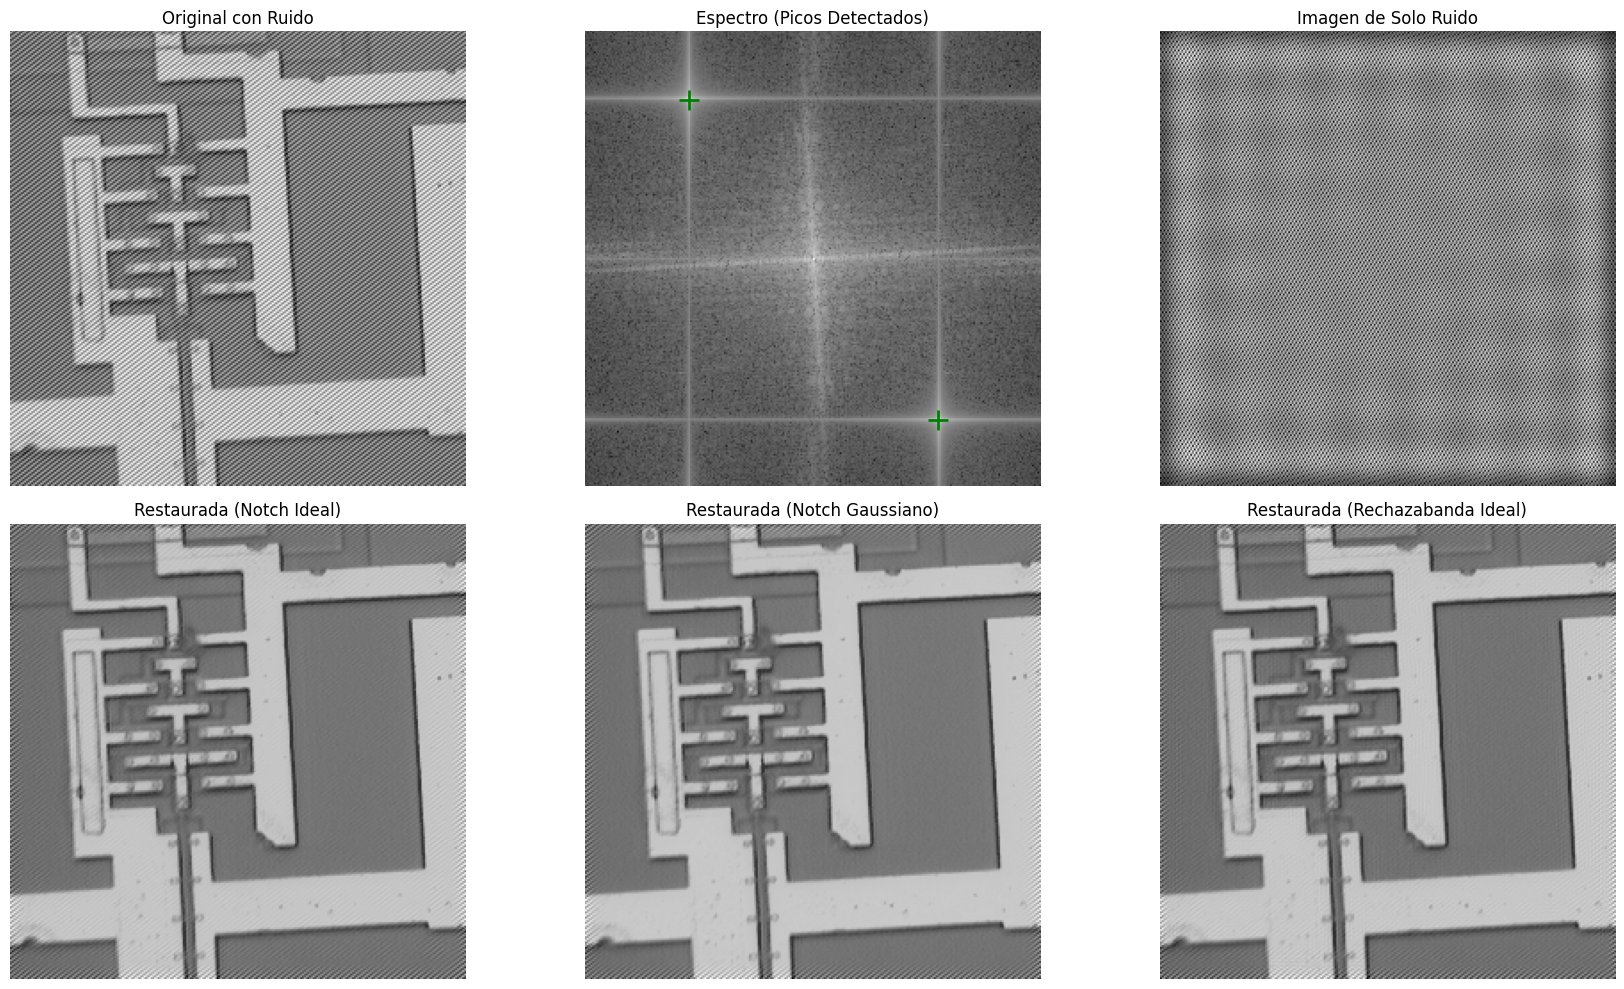

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def ruido_periodico(img_path='img_degradada.tif', img_original_path='img.tif'):
    # Cargar imagen degradada
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: 
        print(f" No se pudo cargar '{img_path}'. Asegurate de tenerla en el directorio.")
        return

    filas, cols = img.shape
    cy, cx = filas // 2, cols // 2

    # 1. Obtener espectro de Fourier
    dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    mag = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1)

    # 2. Localizar picos fundamentales del ruido de forma AUTOMÁTICA
    # Creamos una copia del espectro y borramos el centro (DC) para buscar solo el ruido externo
    mag_sin_centro = mag.copy()
    r_centro = 30
    cv2.circle(mag_sin_centro, (cx, cy), r_centro, 0, -1)
    
    # Encontramos el punto más brillante fuera del centro
    _, _, _, max_loc = cv2.minMaxLoc(mag_sin_centro)
    u0, v0 = max_loc[0], max_loc[1]
    
    # Calculamos el desplazamiento respecto al centro de la imagen
    disp_x = u0 - cx
    disp_y = v0 - cy
    print(f"--- Análisis Frecuencial ---")
    print(f"Pico de ruido localizado automáticamente en: (u={u0}, v={v0})")
    print(f"Pico conjugado simétrico localizado en:      (u={cx - disp_x}, v={cy - disp_y})")

    # 3. Implementación de Máscaras de Filtrado (Notch y Rechazabanda)
    # Inicializamos máscaras con 1s (dejan pasar todo)
    mask_notch_ideal = np.ones((filas, cols, 2), np.float32)
    mask_notch_gauss = np.ones((filas, cols, 2), np.float32)
    mask_rechazabanda = np.ones((filas, cols, 2), np.float32)
    
    radio_notch = 8
    D0_banda = np.sqrt(disp_x**2 + disp_y**2) 
    ancho_banda = 15
    
    v_grid, u_grid = np.meshgrid(np.arange(cols), np.arange(filas))
    
    # Distancias a los dos picos de ruido simétricos
    D1 = np.sqrt((u_grid - v0)**2 + (v_grid - u0)**2)
    D2 = np.sqrt((u_grid - (cy - disp_y))**2 + (v_grid - (cx - disp_x))**2)
    # Distancia al centro para el Rechazabanda
    D_centro = np.sqrt((u_grid - cy)**2 + (v_grid - cx)**2)

    # --- A) Filtro Notch Ideal ---
    cv2.circle(mask_notch_ideal, (u0, v0), radio_notch, (0, 0), -1)
    cv2.circle(mask_notch_ideal, (cx - disp_x, cy - disp_y), radio_notch, (0, 0), -1)

    # --- B) Filtro Notch Gaussiano ---
    h_gauss = (1.0 - np.exp(-D1**2 / (2 * (radio_notch**2)))) * (1.0 - np.exp(-D2**2 / (2 * (radio_notch**2))))
    mask_notch_gauss[:,:,0] = h_gauss
    mask_notch_gauss[:,:,1] = h_gauss

    # --- C) Filtro Rechazabanda Ideal ---
    condicion_banda = (D_centro >= (D0_banda - ancho_banda/2)) & (D_centro <= (D0_banda + ancho_banda/2))
    mask_rechazabanda[condicion_banda] = 0

    # 4. Filtrar y transformar de vuelta (IDFT)
    def aplicar_filtro_y_regresar(dft_src, mascara):
        fshift_filtrado = dft_src * mascara
        f_ishift = np.fft.ifftshift(fshift_filtrado)
        
        # LA MAGIA ESTÁ ACÁ: Agregamos cv2.DFT_SCALE para que escale los valores correctamente
        img_back = cv2.idft(f_ishift, flags=cv2.DFT_SCALE | cv2.DFT_COMPLEX_OUTPUT)
        img_back_mag = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])
        
        return np.clip(img_back_mag, 0, 255).astype(np.uint8)

    img_restaurada_ideal = aplicar_filtro_y_regresar(dft_shift, mask_notch_ideal)
    img_restaurada_gauss = aplicar_filtro_y_regresar(dft_shift, mask_notch_gauss)
    img_restaurada_banda = aplicar_filtro_y_regresar(dft_shift, mask_rechazabanda)

    # 5. Imagen de SOLO RUIDO (Notch Pasante / Invertido)
    mask_notch_pasante = 1.0 - mask_notch_ideal
    img_solo_ruido = aplicar_filtro_y_regresar(dft_shift, mask_notch_pasante)

    # 6. Evaluación Cuantitativa 
    img_original = cv2.imread(img_original_path, cv2.IMREAD_GRAYSCALE)
    print("\n--- Evaluación Cuantitativa (ECM) ---")
    if img_original is not None:
        def mse(a, b): return np.sum((a.astype("float") - b.astype("float"))**2) / float(a.size)
        print(f"ECM Imagen Degradada:          {mse(img_original, img):.2f}")
        print(f"ECM Restaurada (Notch Ideal):   {mse(img_original, img_restaurada_ideal):.2f}")
        print(f"ECM Restaurada (Notch Gauss):   {mse(img_original, img_restaurada_gauss):.2f}")
        print(f"ECM Restaurada (Rechazabanda):  {mse(img_original, img_restaurada_banda):.2f}")
    else:
        print("Subir 'img.tif'")

    # --- Visualización de Resultados ---
    plt.figure(figsize=(18, 10))
    
    plt.subplot(2, 3, 1); plt.imshow(img, cmap='gray'); plt.title('Original con Ruido'); plt.axis('off')
    plt.subplot(2, 3, 2); plt.imshow(mag, cmap='gray'); plt.title('Espectro (Picos Detectados)'); plt.axis('off')
    
    plt.plot(u0, v0, 'g+', markersize=15, markeredgewidth=2)
    plt.plot(cx - disp_x, cy - disp_y, 'g+', markersize=15, markeredgewidth=2)
    
    plt.subplot(2, 3, 3); plt.imshow(img_solo_ruido, cmap='gray'); plt.title('Imagen de Solo Ruido'); plt.axis('off')
    plt.subplot(2, 3, 4); plt.imshow(img_restaurada_ideal, cmap='gray'); plt.title('Restaurada (Notch Ideal)'); plt.axis('off')
    plt.subplot(2, 3, 5); plt.imshow(img_restaurada_gauss, cmap='gray'); plt.title('Restaurada (Notch Gaussiano)'); plt.axis('off')
    plt.subplot(2, 3, 6); plt.imshow(img_restaurada_banda, cmap='gray'); plt.title('Restaurada (Rechazabanda Ideal)'); plt.axis('off')
    
    plt.tight_layout()
    plt.show()

ruido_periodico('img_degradada.tif', 'img.tif')

### Reflexiones: Eliminación de Ruido Periódico

* **Ruido senoidal en el espectro:** Una onda senoidal pura se caracteriza por tener una única frecuencia y dirección espacial. Por las propiedades matemáticas de la Transformada de Fourier, este tipo de onda se representa en el espectro como **un par de impulsos simétricos (deltas)** alejados del centro (componente DC). La distancia de estos puntos al centro indica la frecuencia de la interferencia, y su ángulo representa la dirección.

* **Rechazabanda vs. Notch Puntual:** La gran desventaja del filtro **rechazabanda** es que elimina un anillo completo de frecuencias, borrando indiscriminadamente detalles y texturas de la imagen que comparten ese mismo radio frecuencial. Por el contrario, el **filtro Notch**: solo bloquea las coordenadas exactas (los píxeles) donde se encuentra el ruido, preservando casi intacta la información de la imagen original.

## Ejercicio 6 Restauración por filtrado de Wiener

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Text

# 1. Modelos de degradación independientes
def respuesta_frecuencia_outoffocus(shape_img, radio):
    mask = np.zeros(shape_img, dtype=np.float32)
    c = (shape_img[1]//2, shape_img[0]//2)
    if radio > 0:
        cv2.circle(mask, c, radio, 1.0, -1)
    else:
        mask[c[1], c[0]] = 1.0
    sum_h = np.sum(mask)
    if sum_h > 0: mask /= sum_h
    return np.fft.fft2(np.fft.ifftshift(mask))

def respuesta_frecuencia_motionblur(shape_img, longitud, theta):
    mask = np.zeros(shape_img, dtype=np.float32)
    c = (shape_img[1]//2, shape_img[0]//2)
    if longitud > 0:
        angulo_rad = np.deg2rad(theta)
        x_off = int(np.cos(angulo_rad) * longitud / 2)
        y_off = int(np.sin(angulo_rad) * longitud / 2)
        cv2.line(mask, (c[0] - x_off, c[1] - y_off), (c[0] + x_off, c[1] + y_off), 1.0, 2)
    else:
        mask[c[1], c[0]] = 1.0
    sum_h = np.sum(mask)
    if sum_h > 0: mask /= sum_h
    return np.fft.fft2(np.fft.ifftshift(mask))

# 2. Función unificada
def restaurar_ambas_imagenes(archivo_foco, SNR_foco, radio, archivo_mov, SNR_mov, longitud, theta):
    # --- PROCESAMIENTO 1: FUERA DE FOCO ---
    img_foco = cv2.imread(archivo_foco, cv2.IMREAD_GRAYSCALE)
    img_est_foco = np.zeros((100, 100))
    if img_foco is not None:
        img_f_foco = img_foco.astype(np.float32) / 255.0
        G_foco = np.fft.fft2(img_f_foco)
        H_foco = respuesta_frecuencia_outoffocus(img_foco.shape, radio)
        K_foco = 1.0 / SNR_foco
        W_foco = np.conj(H_foco) / (np.abs(H_foco)**2 + K_foco)
        img_est_foco = np.real(np.fft.ifft2(W_foco * G_foco))
        img_est_foco = np.clip(img_est_foco, 0, 1)

    # --- PROCESAMIENTO 2: DESENFOQUE POR MOVIMIENTO ---
    img_mov = cv2.imread(archivo_mov, cv2.IMREAD_GRAYSCALE)
    img_est_mov = np.zeros((100, 100))
    if img_mov is not None:
        img_f_mov = img_mov.astype(np.float32) / 255.0
        G_mov = np.fft.fft2(img_f_mov)
        H_mov = respuesta_frecuencia_motionblur(img_mov.shape, longitud, theta)
        
        # Filtro de Wiener
        K_mov = 1.0 / SNR_mov
        W_mov = np.conj(H_mov) / (np.abs(H_mov)**2 + K_mov)
        img_est_mov = np.real(np.fft.ifft2(W_mov * G_mov))
        img_est_mov = np.clip(img_est_mov, 0, 1)

    # --- GRAFICACIÓN ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    if img_foco is not None:
        axes[0, 0].imshow(img_foco, cmap="gray")
        axes[0, 0].set_title(f"Original Fuera de Foco: {archivo_foco}")
        axes[0, 1].imshow(img_est_foco, cmap="gray")
        axes[0, 1].set_title(f"Restaurada (Radio={radio} | SNR={SNR_foco})")
    
    if img_mov is not None:
        axes[1, 0].imshow(img_mov, cmap="gray")
        axes[1, 0].set_title(f"Original Movimiento: {archivo_mov}")
        axes[1, 1].imshow(img_est_mov, cmap="gray")
        axes[1, 1].set_title(f"Restaurada (Long={longitud} | Ang={theta}° | SNR={SNR_mov})")
        
    for row in axes:
        for ax in row: ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# 3. Interfaz con rangos extendidos
interact(restaurar_ambas_imagenes,
         archivo_foco=Text(value='borrosa.jpg', description='Ruta Foco:'),
         SNR_foco=IntSlider(value=250, min=1, max=1000, step=1, description='SNR Foco:'),
         radio=IntSlider(min=1, max=50, value=6, description='Radio:'),
         archivo_mov=Text(value='movimiento.jpg', description='Ruta Mov:'),
         SNR_mov=IntSlider(value=33, min=1, max=1000, step=1, description='SNR Mov:'),
         longitud=IntSlider(min=1, max=150, value=1, description='Longitud:'),
         theta=IntSlider(min=-90, max=90, value=20, description='Ángulo:'))

interactive(children=(Text(value='borrosa.jpg', description='Ruta Foco:'), IntSlider(value=250, description='S…

<function __main__.restaurar_ambas_imagenes(archivo_foco, SNR_foco, radio, archivo_mov, SNR_mov, longitud, theta)>

## Ejercicio 7 Aplicación

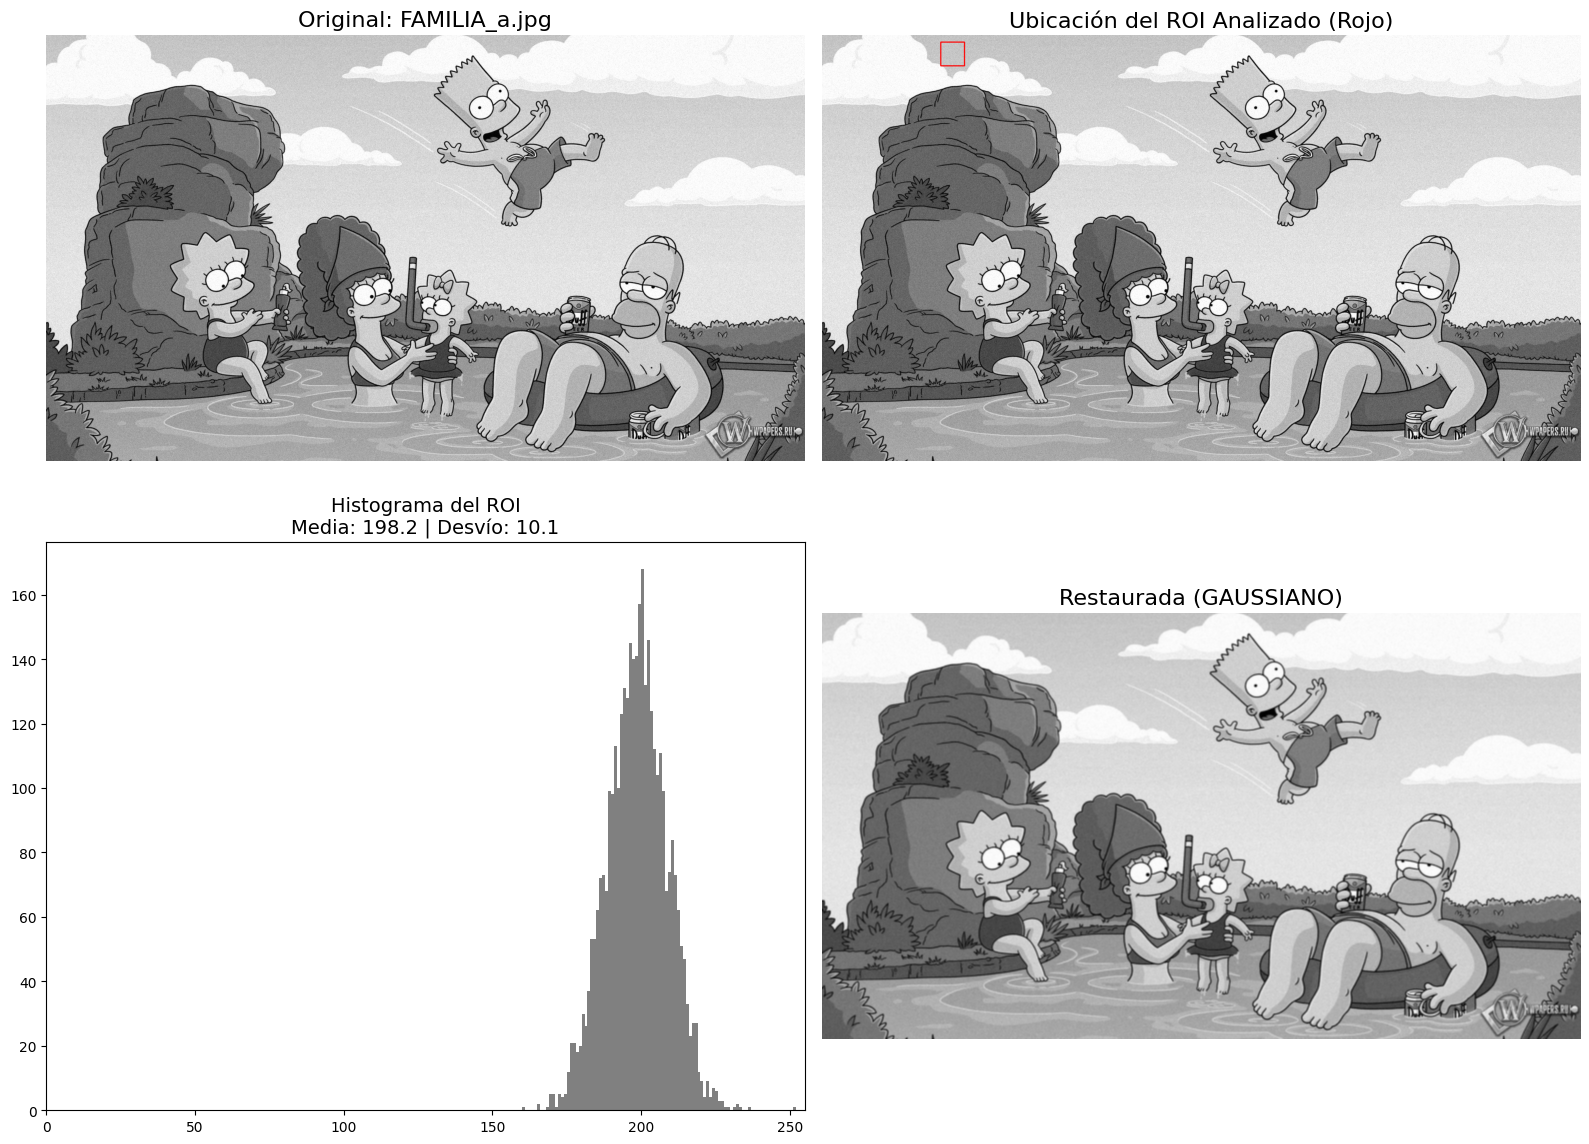

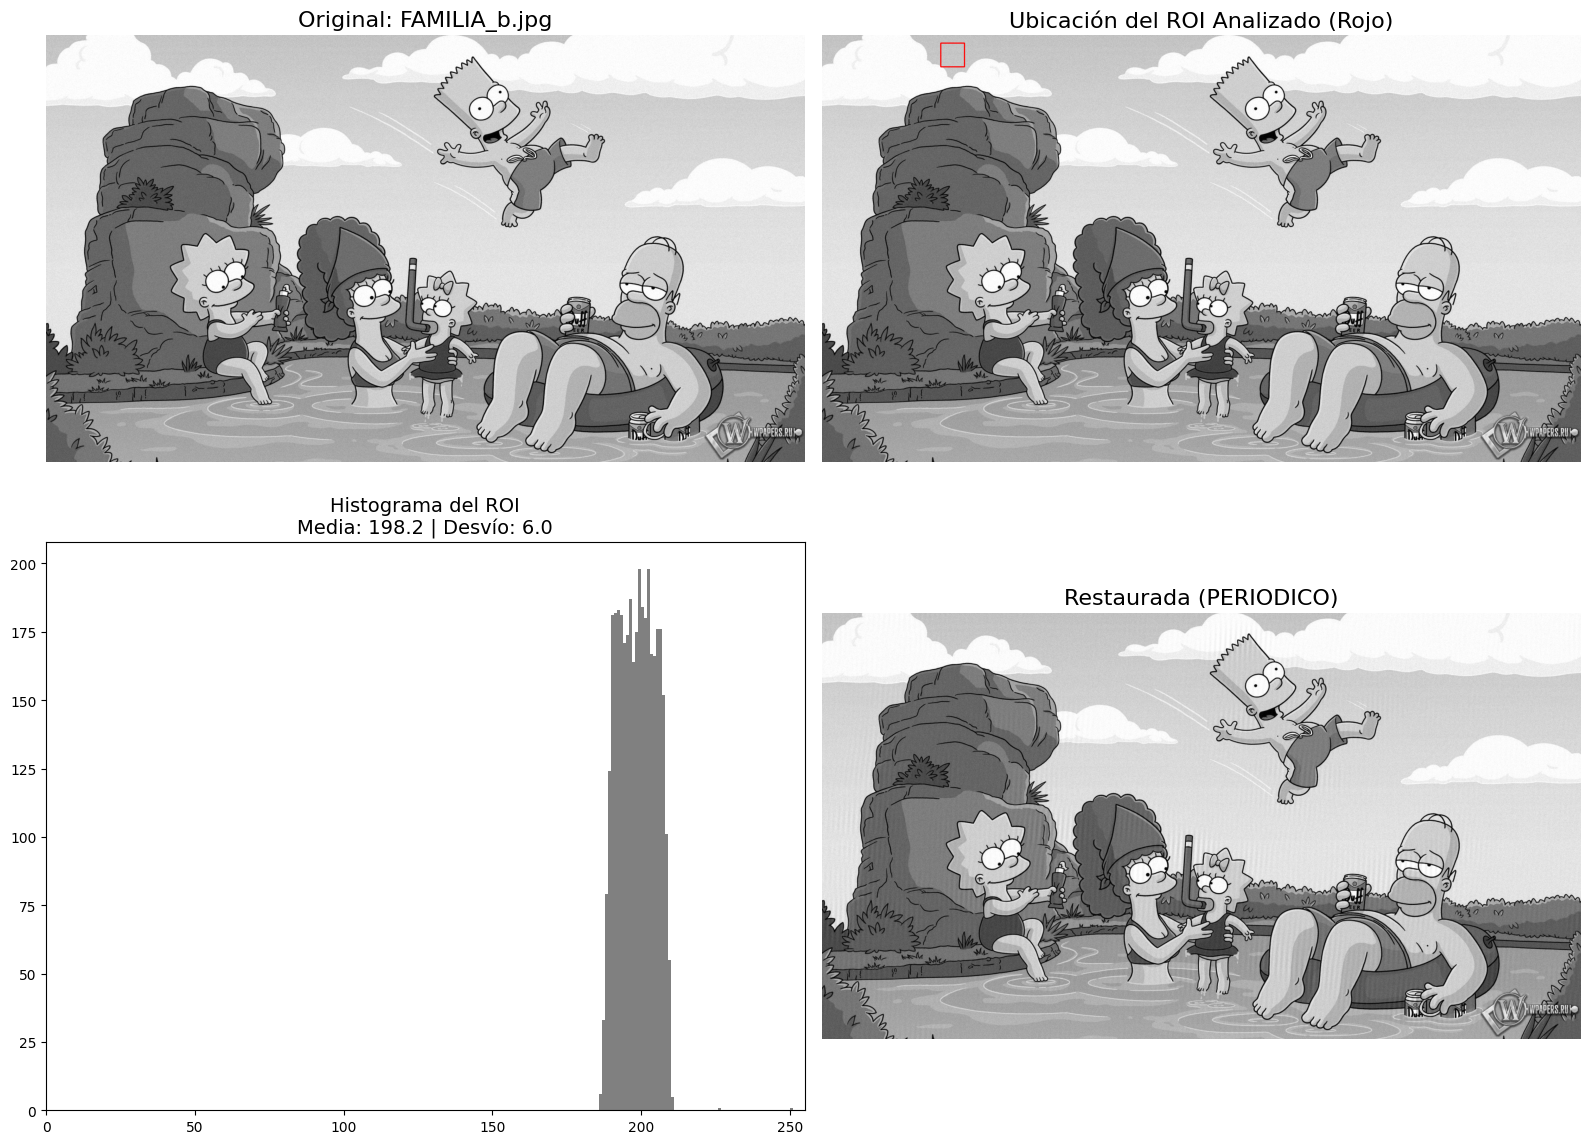

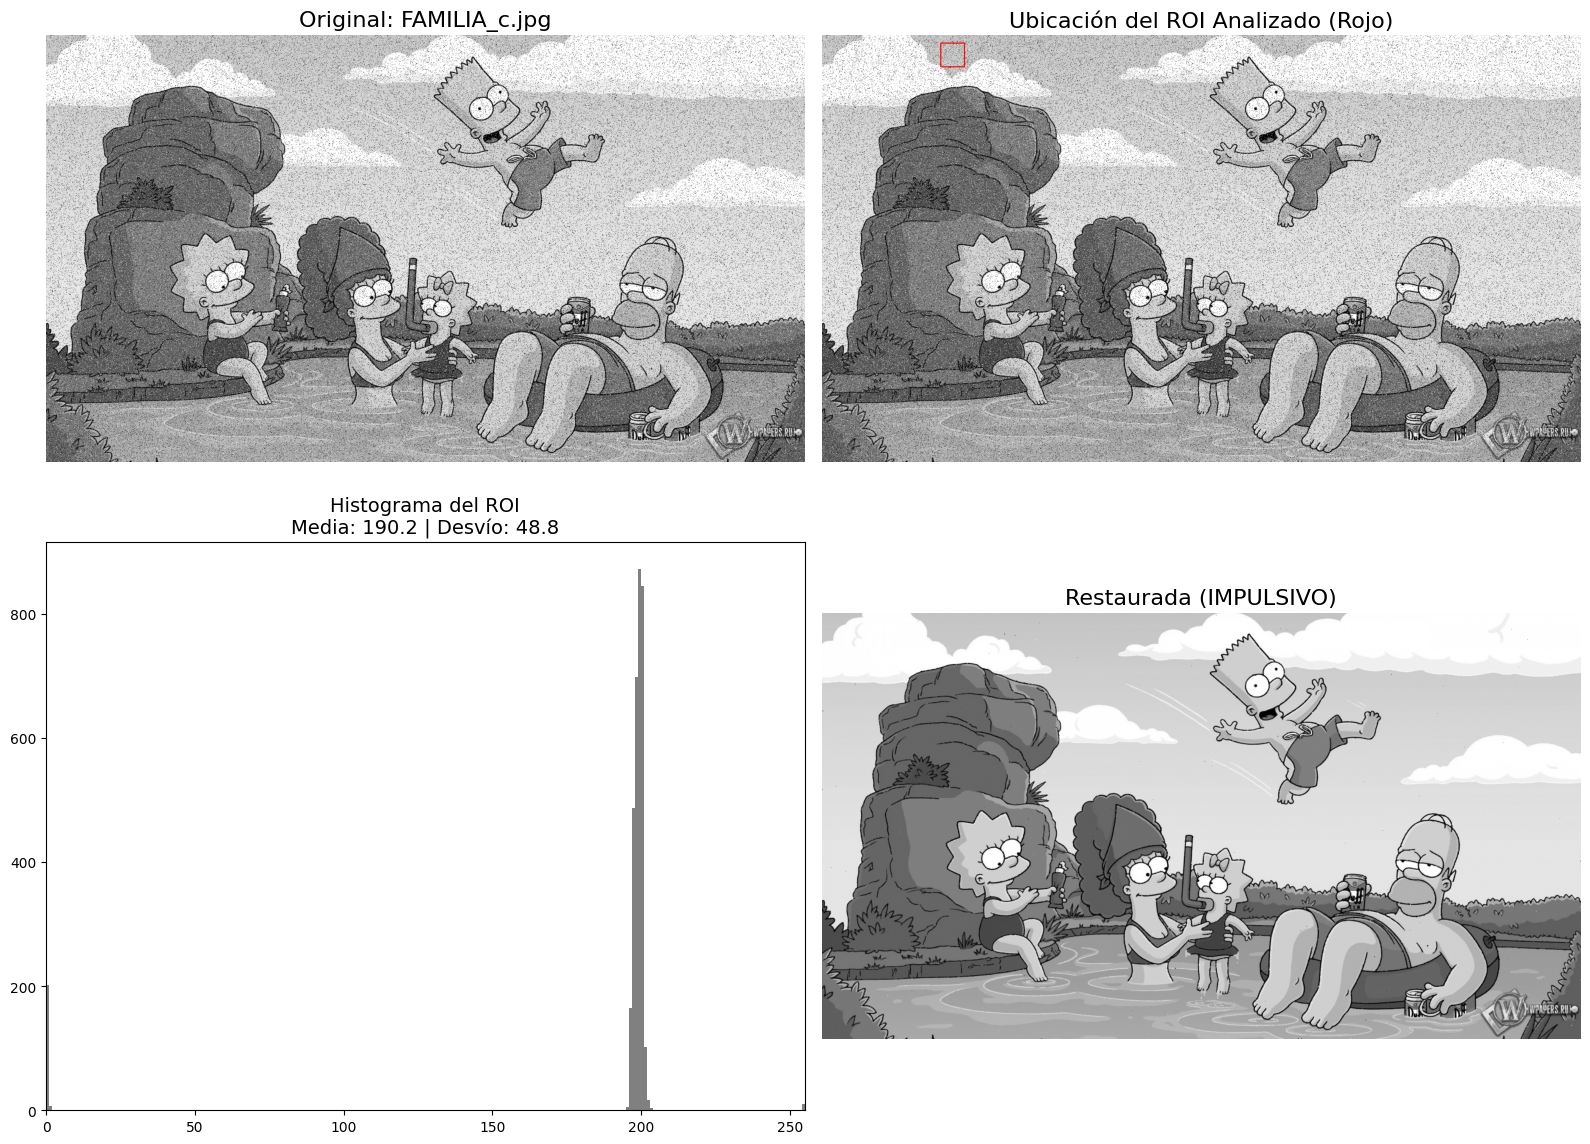

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def aplicacion_familia(img_path, roi_y, roi_x, tipo_diagnostico):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: 
        print(f"Error: No se encontró '{img_path}'.")
        return

    # 1. Seleccionar ROI
    y1, y2 = roi_y
    x1, x2 = roi_x
    roi = img[y1:y2, x1:x2]

    media = np.mean(roi)
    desvio = np.std(roi)
    
    img_restaurada = np.zeros_like(img)
    
    if tipo_diagnostico == 'gaussiano':
        img_restaurada = cv2.blur(img, (5, 5))
        
    elif tipo_diagnostico == 'impulsivo':
        img_restaurada = cv2.medianBlur(img, 3)
        
    elif tipo_diagnostico == 'periodico':
        dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
        dft_shift = np.fft.fftshift(dft)
        mag = cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1])
        
        cy, cx = img.shape[0]//2, img.shape[1]//2
        cv2.circle(mag, (cx, cy), 150, 0, -1) 
        _, _, _, max_loc = cv2.minMaxLoc(mag)
        u0, v0 = max_loc
        disp_x, disp_y = u0 - cx, v0 - cy
        
        mask = np.ones((img.shape[0], img.shape[1], 2), np.float32)
        cv2.circle(mask, (u0, v0), 10, (0,0), -1)
        cv2.circle(mask, (cx - disp_x, cy - disp_y), 10, (0,0), -1)
        
        f_ishift = np.fft.ifftshift(dft_shift * mask)
        img_back = cv2.idft(f_ishift, flags=cv2.DFT_SCALE | cv2.DFT_COMPLEX_OUTPUT)
        img_restaurada = np.clip(cv2.magnitude(img_back[:,:,0], img_back[:,:,1]), 0, 255).astype(np.uint8)

    # Visualización 2x2
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    
    axs[0, 0].imshow(img, cmap='gray')
    axs[0, 0].set_title(f'Original: {img_path}', fontsize=16)
    axs[0, 0].axis('off')
    
    img_roi_box = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    cv2.rectangle(img_roi_box, (x1, y1), (x2, y2), (255, 0, 0), 2)
    axs[0, 1].imshow(img_roi_box)
    axs[0, 1].set_title('Ubicación del ROI Analizado (Rojo)', fontsize=16)
    axs[0, 1].axis('off')
    
    axs[1, 0].hist(roi.ravel(), bins=256, range=(0, 256), color='gray')
    axs[1, 0].set_title(f'Histograma del ROI\nMedia: {media:.1f} | Desvío: {desvio:.1f}', fontsize=14)
    axs[1, 0].set_xlim(0, 255)
    
    axs[1, 1].imshow(img_restaurada, cmap='gray')
    axs[1, 1].set_title(f'Restaurada ({tipo_diagnostico.upper()})', fontsize=16)
    axs[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()


# ==========================================================
coords_y = [20, 80]
coords_x = [300, 360]
#coords_y = [550, 650]
#coords_x = [230, 300]

aplicacion_familia('FAMILIA_a.jpg', roi_y=coords_y, roi_x=coords_x, tipo_diagnostico='gaussiano')

aplicacion_familia('FAMILIA_b.jpg', roi_y=coords_y, roi_x=coords_x, tipo_diagnostico='periodico')


aplicacion_familia('FAMILIA_c.jpg', roi_y=coords_y, roi_x=coords_x, tipo_diagnostico='impulsivo')



### Ejercicio 7 — Análisis y Justificación

**FAMILIA_a — Ruido Gaussiano → Filtro de medias**
El histograma del ROI muestra una distribución simétrica en campana centrada en ~200, con desvío estándar de 10.1. Esto se asemeja a la distribución gaussiana, donde el ruido es aditivo con media cero y varianza finita. El filtro de medias es el más apto porque promedia los valores vecinos, cancelando el ruido por ser de media cero sin distorsionar la estructura de la imagen.

**FAMILIA_b — Ruido Periódico → Filtro Notch (Fourier)**
El histograma del ROI está muy concentrado (desvío 6.0), lo que indica que el ruido no es aleatorio sino estructurado. En el dominio frecuencial aparecen picos de energía fuera del centro que delatan la interferencia senoidal. El filtro Notch es el más apto porque actúa directamente sobre esas frecuencias específicas, anulándolas sin tocar el resto del espectro de la imagen.

**FAMILIA_c — Ruido Impulsivo → Filtro de mediana**
El histograma del ROI muestra un pico estrecho y alto con valores 190 y 210 distribución característica del ruido sal y pimienta. El filtro de mediana es el más apto porque reemplaza cada píxel por el valor central de su vecindad, eliminando los impulsos extremos sin calcular un promedio que los propagaría al resto de la imagen.